# Import Variables and Load Packages

In [156]:
import uproot
#print("uproot version: ", uproot.__version__)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
import pickle
from collections import Counter
from particle import Particle
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import awkward as ak
import matplotlib.patches as patches

f = uproot.open('/Users/katherinepulido/Desktop/H-KPMTcalibration/HKPMTcalibration/LIGen395_Pos0_DROff_hits_flat (1).root')

print(f['photonTree;2'].keys())
print(f['hitsTree'].keys())


f.keys()


['event', 'subevent', 'tubeId', 'startX', 'startY', 'startZ', 'endX', 'endY', 'endZ', 'endDirX', 'endDirY', 'endDirZ', 'normX', 'normY', 'normZ']
['event', 'subevent', 'pmt_id', 'charge', 'time', 'posX', 'posY', 'posZ']


['photonTree;2', 'photonTree;1', 'hitsTree;1']

## Load Variables

In [157]:
photon = ['event', 'subevent', 'tubeId', 'startX', 'startY', 'startZ', 'endX', 'endY', 'endZ', 'endDirX', 'endDirY', 'endDirZ', 'normX', 'normY', 'normZ']

hits = ['event', 'subevent', 'pmt_id', 'charge', 'time', 'posX', 'posY', 'posZ']

vars = {}
vars2 = {}
vars.update(f["photonTree"].arrays(photon, library="np"))
vars2.update(f["hitsTree"].arrays(hits, library="np"))

for key, value in vars.items():
    print(f"{key}: {len(value)}")

for key, value in vars2.items():
    print(f"{key}: {len(value)}")
    
for col in tqdm(vars):
    vars[col] = vars[col].tolist()
    
for col in tqdm(vars2):
    vars2[col] = vars2[col].tolist()

ph_df = pd.DataFrame(vars)
hit_df = pd.DataFrame(vars2)

ph_df.shape, hit_df.shape

# print highest event value for ph_df
print("photon event max for hit_df: ", hit_df['event'].max())

event: 938651
subevent: 938651
tubeId: 938651
startX: 938651
startY: 938651
startZ: 938651
endX: 938651
endY: 938651
endZ: 938651
endDirX: 938651
endDirY: 938651
endDirZ: 938651
normX: 938651
normY: 938651
normZ: 938651
event: 839337
subevent: 839337
pmt_id: 839337
charge: 839337
time: 839337
posX: 839337
posY: 839337
posZ: 839337


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

photon event max for hit_df:  9999


In [158]:
# some global variables

radius = 3242.76611328125
height = 2*3296.47119140625

xmin = -3242.76611328125
xmax = 3242.76611328125
ymin = -3242.76611328125
ymax = 3242.76611328125
zmin = -3296.47119140625
zmax = 3296.47119140625

# can one photon hit on two pmts?

# make a pmt dictionary with pmt_type 

pmt_dict = {
    row.pmt_id: (row.posX, row.posY, row.posZ)
    for row in hit_df[['pmt_id', 'posX', 'posY', 'posZ']]
        .drop_duplicates(subset='pmt_id')
        .itertuples(index=False)
}

for pmt in pmt_dict:
    if np.isclose(pmt_dict[pmt][2], 3296.47119140625):
        pmt_dict[pmt] = (*pmt_dict[pmt][:3], 'top')
    elif np.isclose(pmt_dict[pmt][2], -3296.47119140625):
        pmt_dict[pmt] = (*pmt_dict[pmt][:3], 'bottom')
    elif np.isclose(np.sqrt(pmt_dict[pmt][0]**2 + pmt_dict[pmt][1]**2), radius, atol=1):
        pmt_dict[pmt] = (*pmt_dict[pmt][:3], 'barrel')

# see if any pmts dont have classification
for pmt in pmt_dict:
    if len(pmt_dict[pmt]) != 4:
        print(f"PMT {pmt} does not have a classification.")

#print(pmt_dict)
    
pmt_dict[1234]

pmt_normals = {}
for row in hit_df[['pmt_id', 'posX', 'posY', 'posZ']].drop_duplicates(subset='pmt_id').itertuples(index=False):
    pmt_id, pmt_x, pmt_y, pmt_z = row.pmt_id, row.posX, row.posY, row.posZ

    # define normal vector
    if pmt_z == 3296.47119140625:
        normal_vector = np.array([0, 0, -1])
    elif pmt_z == -3296.47119140625:
        normal_vector = np.array([0, 0, 1])
    else:
        normal_vector = np.array([-pmt_x/radius, -pmt_y/radius, 0])

    # normalize
    normal_vector = normal_vector / np.linalg.norm(normal_vector)

    # store in separate dict
    pmt_normals[pmt_id] = normal_vector
    


In [159]:
# some universally used functions

def get_pmt_normal(pmt_id):
    """Return the normal vector for a PMT, with top/bottom special cases."""
    x, y, z = pmt_dict[pmt_id]
    
    # Top / bottom check
    if np.isclose(z, 3296.47119140625):
        return np.array([0, 0, -1])
    elif np.isclose(z, -3296.47119140625):
        return np.array([0, 0, 1])
    
    # Otherwise, use the stored normal
    n = np.array(pmt_normals[pmt_id])
    return n / np.linalg.norm(n)

def get_charge(pmt_id): # sum of charge column in hit_df (hit_df['charge']) for a given pmt id
    return hit_df[hit_df['pmt_id'] == pmt_id]['charge'].sum()

def get_hit_count(pmt_id):
    return hit_counts.get(pmt_id, 0)

charge_by_pmt = hit_df.groupby('pmt_id')['charge'].sum()

def get_charge(pmt_id):
    return charge_by_pmt.get(pmt_id, 0.0)

pmt_lookup = (
    hit_df[['pmt_id', 'posX', 'posY', 'posZ']]
    .drop_duplicates(subset='pmt_id')
    .set_index('pmt_id')
)

all_pmt_ids = pmt_lookup.index.values
positions = pmt_lookup[['posX','posY','posZ']].values

hit_counts = hit_df['pmt_id'].value_counts()

print(pmt_lookup.loc[all_pmt_ids[0]])
print(positions[0])

def get_nearest_pmts(pmt_id, k):
    if pmt_id not in pmt_lookup.index:
        raise ValueError(f"PMT {pmt_id} not found")

    target = pmt_lookup.loc[pmt_id].values

    # compute distances
    dists = np.linalg.norm(positions - target, axis=1)
    mask = all_pmt_ids != pmt_id

    nearest_idx = np.argsort(dists[mask])[:k]
    nearest_pmts = all_pmt_ids[mask][nearest_idx]
    
    
    return nearest_pmts

neighbors = get_nearest_pmts(pmt_id, 50)

print("Returned:", len(neighbors))
print("Unique:", len(set(neighbors)))
print("Contains self:", pmt_id in neighbors)

posX    3241.222900
posY     106.106651
posZ   -2543.196045
Name: 13008, dtype: float64
[ 3241.22290039   106.10665131 -2543.19604492]
Returned: 50
Unique: 50
Contains self: False


# Define Individual Subplots

<Axes: title={'center': 'Full Cylinder View'}, xlabel='Distance around barrel (cm)', ylabel='Height (cm)'>

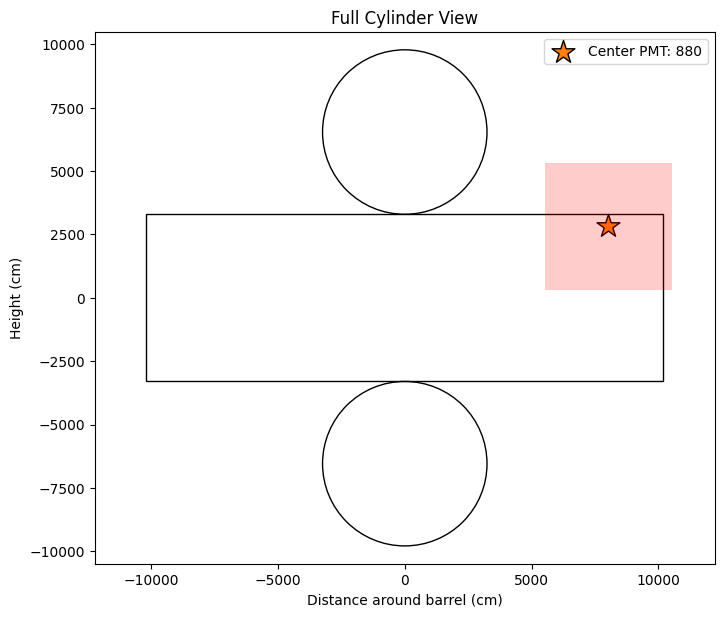

In [186]:
# location, FOV on unrolled cylinder

def pmt_on_cylinder_net(pmt_ids, pmt_info, fov_size, info_label, dot_size, show_vals=False, ax_barrel=None):
    if ax_barrel is None:
        fig, ax_barrel = plt.subplots(1, 1, figsize=(8, 8))
    
    # some vars that are globally relevant
    center_pmt = pmt_ids[0]
    #n = get_pmt_normal(center_pmt)
    n = pmt_normals[center_pmt]
    cent_x, cent_y, cent_z, cent_type = pmt_dict[center_pmt]
    
    # full barrel plot
    rect = Rectangle((-np.pi*radius, -height/2), 2*np.pi*radius, height, edgecolor='black', facecolor='none')
    ax_barrel.add_patch(rect)
    top_circle = Circle((0, height/2 + radius), radius, edgecolor='black', facecolor='none')
    ax_barrel.add_patch(top_circle)
    bottom_circle = Circle((0, (-height/2)-radius), radius, edgecolor='black', facecolor='none')
    ax_barrel.add_patch(bottom_circle)
    
    ax_barrel.set_xlim(-1.2*np.pi*radius, 1.2*np.pi*radius)
    ax_barrel.set_ylim(-1.2*radius - height, 1.2*radius + height)
    ax_barrel.set_aspect('equal')
    ax_barrel.set_xlabel("Distance around barrel (cm)")
    ax_barrel.set_ylabel("Height (cm)")
    ax_barrel.set_title("Full Cylinder View")
    
    if cent_type == 'top':
        star_x = cent_x          # x-coordinate in barrel plot
        star_z = cent_y + radius + height/2  # place on top circle
        roi = Rectangle(
            (cent_x - fov_size/2, (cent_y + radius + height/2) - fov_size/2),
            fov_size, fov_size,
            facecolor='red', alpha=0.2
        )
    elif cent_type == 'bottom':
        star_x = cent_x
        star_z = cent_y - radius - height/2  # place on bottom circle
        roi = Rectangle(
            (cent_x - fov_size/2, (cent_y - radius - height/2) - fov_size/2),
            fov_size, fov_size,
            facecolor='red', alpha=0.2
        )
    elif cent_type == 'barrel':
        phi = np.arctan2(cent_y, cent_x)
        star_x = radius * phi
        star_z = cent_z
        roi = Rectangle(
            (star_x - fov_size/2, star_z - fov_size/2),
            fov_size, fov_size,
            facecolor='red', alpha=0.2
        )
    
        # Plot center PMT as a star
    ax_barrel.scatter(
        star_x, star_z,
        marker='*',
        color='#FF7F0E',  # bright orange
        s=300,
        edgecolors='k',
        label=f'Center PMT: {center_pmt}'
    )
    
    ax_barrel.add_patch(roi)
    ax_barrel.legend(loc='upper right')

    
    if ax_barrel is None:
        plt.show()
    return ax_barrel
    
pmt_on_cylinder_net(
    pmt_ids=[880],
    pmt_info=pmt_dict,
    fov_size=5000,  # example FOV size in cm
    info_label='Charge',
    dot_size=100,
    show_vals=False
)
    

(-3141.42724609375, 805.1204833984375, -1058.83203125, 'barrel')


/var/folders/_s/7j_881g14zd1rn9kv4_hn7nw0000gn/T/ipykernel_89702/2508467033.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


<Axes: title={'center': 'Perspective View Along PMT Normal'}, xlabel='Distance Projected Along u (cm)', ylabel='Distance Projected Along v (cm)'>

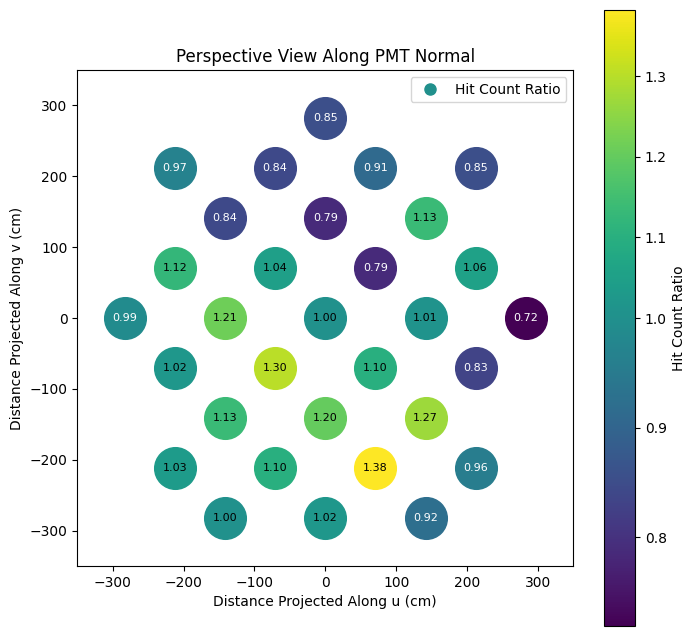

In [218]:
# hit ratio neighbors

def hit_ratio_of_neighbors(pmt_ids, pmt_info, fov_size, info_label, dot_size, show_vals=False, ax_persp=None):
    if ax_persp is None:
        fig, ax_persp = plt.subplots(1, 1, figsize=(8, 8))
    
    print(pmt_dict[pmt_ids[0]])
    pmt_x, pmt_y, pmt_z, type = pmt_dict[pmt_ids[0]]
    if type == 'top':
        u = np.array([1,0,0])
        v = np.array([0,-1,0])
    elif type == 'bottom':
        u = np.array([1,0,0])
        v = np.array([0,1,0])
    elif type == 'barrel':
        n = pmt_normals[pmt_ids[0]]
        u = np.cross([0,0,1], n)  # u is perpendicular to both z and n (phi hat)
        u /= np.linalg.norm(u)      # normalize, just in case
        v = np.cross(n, u)          # v is perpendicular to n and u, (should be z hat)
    
    info_array = np.array(pmt_info, dtype=float)
    center_value = info_array[0]
    

    # Avoid division by zero
    if center_value == 0:
        print("Warning: Center PMT has zero value for info. Normalization will be skipped.")
        center_value = 1.0  # Prevent division by zero, but this means values
    # Normalize relative to center
    info_array = info_array / center_value

    # Robust normalization centered at 1
    vmin = info_array.min()
    vmax = info_array.max() + 1e-6
    

    # Ensure valid ordering for TwoSlopeNorm
    if vmin == vmax:
        vmin -= 1e-6
        vmax += 1e-6

    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)

    # Colormap
    cmap = cm.get_cmap('viridis')

    for i, (pmt_id, info) in enumerate(zip(pmt_ids, info_array)):
        pos = np.array([pmt_dict[pmt_id][0], pmt_dict[pmt_id][1], pmt_dict[pmt_id][2]]) - np.array([pmt_x, pmt_y, pmt_z])  # relative position to center PMT
        x_proj = np.dot(pos, u)
        y_proj = np.dot(pos, v)

        color = cmap(norm(info))

        sc = ax_persp.scatter(
            x_proj, y_proj,
            c=[color],
            s=dot_size,
            label=info_label if i == 0 else None,
            zorder=2
        )

        if show_vals:
            text_color = 'white' if norm(info) < 0.5 else 'black'
            ax_persp.text(
                x_proj, y_proj,
                f"{info:.2f}",
                ha='center', va='center',
                fontsize=8,
                color=text_color,
                zorder=3
            )
        #print(f"PMT {pmt_id}: info={info}, projected=({x_proj:.1f},{y_proj:.1f}), marker_size={marker_size:.1f}")
    legend_dot = Line2D(
        [0], [0], 
        marker='o', 
        color='w',                  # line itself invisible
        markerfacecolor='#21908C',  # fill color of dot
        markeredgecolor='#21908C',  # optional: edge color
        markersize=8, 
        label=info_label)
    ax_persp.legend(handles=[legend_dot], loc='upper right')
    
    ax_persp.set_xlim(-fov_size/2, fov_size/2)
    ax_persp.set_ylim(-fov_size/2, fov_size/2)
    ax_persp.set_xlabel("Distance Projected Along u (cm)")
    ax_persp.set_ylabel("Distance Projected Along v (cm)")
    ax_persp.set_aspect('equal')
    ax_persp.set_title("Perspective View Along PMT Normal")
    ax_persp.tick_params(axis='both', which='both', labelsize=10)
    
    # show bar for cmap
    sm = cm.ScalarMappable(cmap='viridis', norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax_persp)
    cbar.set_label(info_label)
    
    if ax_persp is None:
        plt.show()
    
    return ax_persp


hit_ratio_of_neighbors(
    pmt_ids,
    pmt_info,
    fov_size=700,  # example FOV size in cm
    info_label='Hit Count Ratio',
    dot_size=900,
    show_vals=True
)



Top 10 PMTs by photon count:
[13007, 19379, 19306, 19308, 19272, 19270, 19343, 19234, 19307, 19342, 19377, 19378, 19344, 19196, 19413, 19412, 19309, 19235, 19198, 19159, 19376, 19160, 19158, 19273, 19341, 19157, 19271, 19195, 19199, 19414, 19237, 19119, 19233, 19197, 19447, 19305, 19446, 19081, 19236, 19411, 19274, 19039, 19345, 19042, 19080, 19304, 19161, 19269, 19445, 19120, 19479, 19118, 19122, 19200, 19380, 19162, 19078, 19310, 19077, 19340, 19079, 19040, 19375, 19238, 19156, 18999, 18958, 18960, 19410, 19232, 19239, 18918, 19041, 19478, 18998, 19002, 19201, 11518, 19082, 19121, 19117, 19448, 19268, 18834, 18959, 19001, 19083, 19194, 18916, 19163, 19415, 19444, 13006, 19038, 18917, 19346, 19231, 18832, 18920, 19043, 19076, 18875, 19381, 19123, 19000, 19155, 19275, 19116, 18915, 18876, 19480, 19339, 19311, 19044, 18919, 18956, 19037, 18873, 18997, 18790, 18749, 18962, 19003, 19124, 18957, 18706, 18750, 18874, 18835, 18877, 19004, 18961, 19303, 18996, 19477, 18872, 19036, 19084, 1870

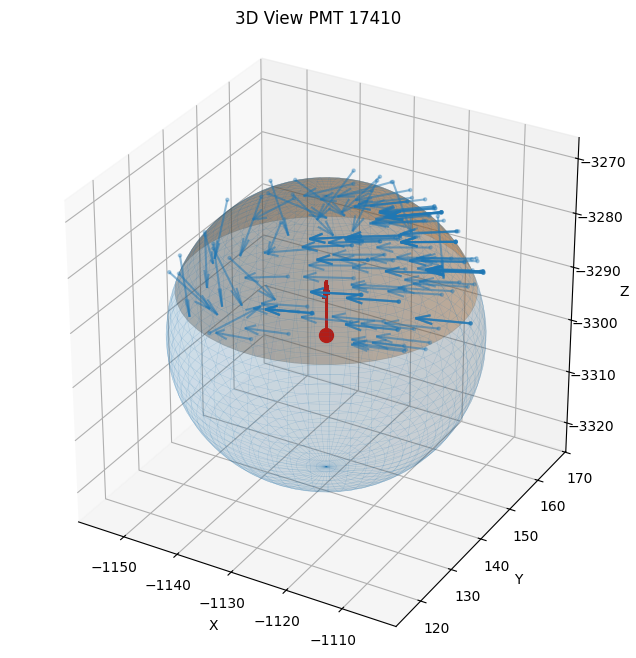

<Axes3D: title={'center': '3D View PMT 17410'}, xlabel='X', ylabel='Y', zlabel='Z'>

In [ ]:
# 3D PMT view with incident photon vectors


    
def pmt_view_3d(pmt_id, max_dist=27, arrow_scale=10, ax=None):
    created_fig=False
    # Create only if needed
    if ax is None:
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')
        created_fig = True
    else:
        # Ensure axis is 3D
        if not hasattr(ax, "get_zlim"):
            raise ValueError("pmt_view_3d requires a 3D axis")
    
    pmt_ph_df = ph_df[ph_df["tubeId"] == pmt_id]
    print(f"{pmt_ph_df.shape[0]} photons")
        
    nx, ny, nz = pmt_normals[pmt_id]

    # photon end points (convert to cm)
    x = pmt_ph_df["endX"].values * 0.1
    y = pmt_ph_df["endY"].values * 0.1
    z = pmt_ph_df["endZ"].values * 0.1

    # direction vectors
    dx = pmt_ph_df["endDirX"].values
    dy = pmt_ph_df["endDirY"].values
    dz = pmt_ph_df["endDirZ"].values

    norm_xs = pmt_ph_df["normX"].values
    norm_ys = pmt_ph_df["normY"].values
    norm_zs = pmt_ph_df["normZ"].values

    # cent pos
    pmt_x, pmt_y, pmt_z, _ = pmt_dict[pmt_id]

    # distance cut 
    #dist = np.sqrt((x - pmt_x)**2 + (y - pmt_y)**2 + (z - pmt_z)**2)
    #mask = dist < max_dist

    #x, y, z = x[mask], y[mask], z[mask]
    #dx, dy, dz = dx[mask], dy[mask], dz[mask]

    #print(f"{len(x)} photons after cut")

    # subsample if too many photons
    #if len(x) > 3000:
    #    idx = np.random.choice(len(x), 3000, replace=False)
    #    x, y, z = x[idx], y[idx], z[idx]
    #    dx, dy, dz = dx[idx], dy[idx], dz[idx]

    # plot

    ax.set_aspect('equal')
    
    r = 25.4  # cm

    u = np.linspace(0, 2*np.pi, 50)
    v = np.linspace(0, np.pi, 50)

    xs = pmt_x + r * np.outer(np.cos(u), np.sin(v))
    ys = pmt_y + r * np.outer(np.sin(u), np.sin(v))
    zs = pmt_z + r * np.outer(np.ones_like(u), np.cos(v))

    # transparent surface
    ax.plot_surface(xs, ys, zs, alpha=0.1)

    # mesh grid overlay
    ax.plot_wireframe(xs, ys, zs, linewidth=0.25, alpha=0.25)
    
    # 70 deg spherical cap
    theta = np.deg2rad(70)

    # normalize normal
    n = np.array([nx, ny, nz])
    n = n / np.linalg.norm(n)

    # build orthonormal basis (u, v, n)
    # pick arbitrary vector not parallel to n
    a = np.array([1, 0, 0])
    if np.allclose(n, a):
        a = np.array([0, 1, 0])

    u_vec = np.cross(n, a)
    u_vec /= np.linalg.norm(u_vec)

    v_vec = np.cross(n, u_vec)

    # parameterize circle
    t = np.linspace(0, 2*np.pi, 100)


    
    # fill spherical cap
    phi = np.linspace(0, 2*np.pi, 50)
    theta_vals = np.linspace(0, theta, 25)

    phi, theta_vals = np.meshgrid(phi, theta_vals)

    cap_x = []
    cap_y = []
    cap_z = []

    for i in range(phi.shape[0]):
        row_x, row_y, row_z = [], [], []
        for j in range(phi.shape[1]):
            dir_vec = (
                np.cos(theta_vals[i,j]) * n +
                np.sin(theta_vals[i,j]) * (
                    np.cos(phi[i,j])*u_vec + np.sin(phi[i,j])*v_vec
                )
            )
            pt = np.array([pmt_x, pmt_y, pmt_z]) + r * dir_vec
            row_x.append(pt[0])
            row_y.append(pt[1])
            row_z.append(pt[2])
        cap_x.append(row_x)
        cap_y.append(row_y)
        cap_z.append(row_z)

    ax.plot_surface(
        np.array(cap_x),
        np.array(cap_y),
        np.array(cap_z),
        alpha=0.3
    )

    # plot photons
    ax.scatter(x, y, z, s=5, alpha=0.3, label="Photon endpoints")

    # arrows associated wiht photons
    ax.quiver(
        x, y, z,
        dx, dy, dz,
        length=arrow_scale,
        normalize=True,
        alpha=0.5
    )
    
    ax.quiver(
        pmt_x, pmt_y, pmt_z,
        norm_xs, norm_ys, norm_zs,
        length=arrow_scale,
         color='red',
         normalize=True,
         alpha=0.5
    )

    # center
    ax.scatter(pmt_x, pmt_y, pmt_z, color='red', s=100, label="PMT center")

    # labels
    ax.set_xlabel("X (cm)")
    ax.set_ylabel("Y (cm)")
    ax.set_zlabel("Z (cm)")
    ax.set_title(f"3D View PMT {pmt_id}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    if created_fig:
        plt.show()

    return ax
    
# get top 10 pmts by count in ph_df

top_pmts = ph_df["tubeId"].value_counts().head(1000).index.tolist()
print("Top 10 PMTs by photon count:")
print(top_pmts)

pmt_view_3d(17410)

103 photons
132 photons
108 photons
111 photons
77 photons
115 photons


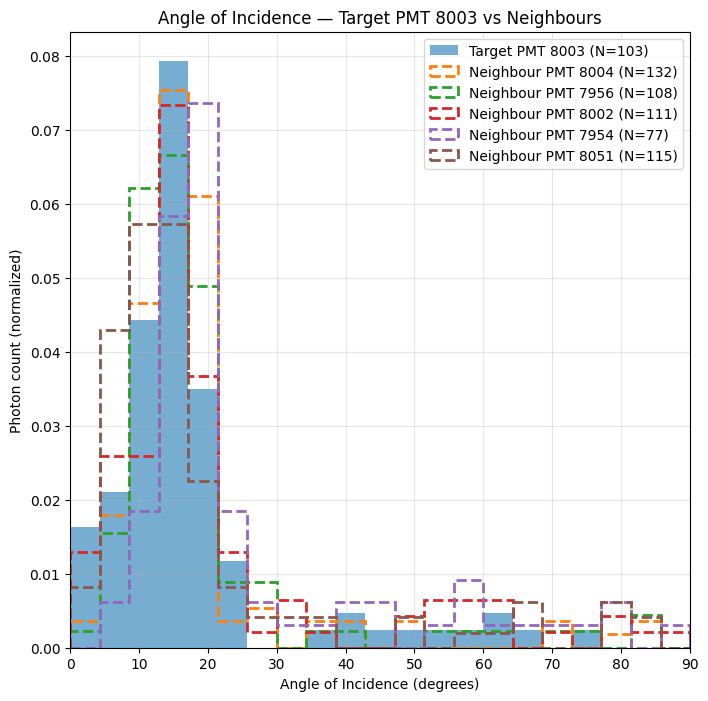

<Axes: title={'center': 'Angle of Incidence — Target PMT 8003 vs Neighbours'}, xlabel='Angle of Incidence (degrees)', ylabel='Photon count (normalized)'>

In [ ]:
# angle of incidence histogram (for pmt + neighbors)

def get_angles(pmt_id):
    pmt_ph_df = ph_df[ph_df["tubeId"] == pmt_id]
    print(f"{pmt_ph_df.shape[0]} photons")

    # direction vectors
    dx = pmt_ph_df["endDirX"].values
    dy = pmt_ph_df["endDirY"].values
    dz = pmt_ph_df["endDirZ"].values

    norm_xs = pmt_ph_df["normX"].values
    norm_ys = pmt_ph_df["normY"].values
    norm_zs = pmt_ph_df["normZ"].values
    
    ph_norm = np.sqrt(dx**2 + dy**2 + dz**2)

    dx /= ph_norm
    dy /= ph_norm
    dz /= ph_norm

    cos_theta = -(
        norm_xs*dx +
        norm_ys*dy +
        norm_zs*dz
    )

    theta = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))
    return theta

def angle_of_incidence_histogram(center_pmt, num_neighbors, ax=None):
    created_fig = False

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        created_fig = True

    neighbor_ids = get_nearest_pmts(center_pmt, num_neighbors)

    # center PMT
    theta_center = get_angles(center_pmt)
    ax.hist(
        theta_center,
        bins=21,
        density=True,
        range=[0, 90],
        alpha=0.6,
        label=f"Target PMT {center_pmt} (N={len(theta_center)})"
    )
    
    # neighbors
    for pid in neighbor_ids:
        theta = get_angles(pid)

        ax.hist(
            theta,
            bins=21,
            density=True,
            histtype='step',
            linestyle='--',
            linewidth=2,
            range=[0, 90],
            label=f"Neighbour PMT {pid} (N={len(theta)})"
        )

    # formatting
    ax.set_xlabel("Angle of Incidence (degrees)")
    ax.set_ylabel("Photon count (normalized)")
    ax.set_title(f"Angle of Incidence — Target PMT {center_pmt} vs Neighbours")
    ax.set_xlim(0, 90)
    ax.grid(alpha=0.3)
    ax.legend()

    if created_fig:
        plt.show()

    return ax
    

angle_of_incidence_histogram(8003, 5)

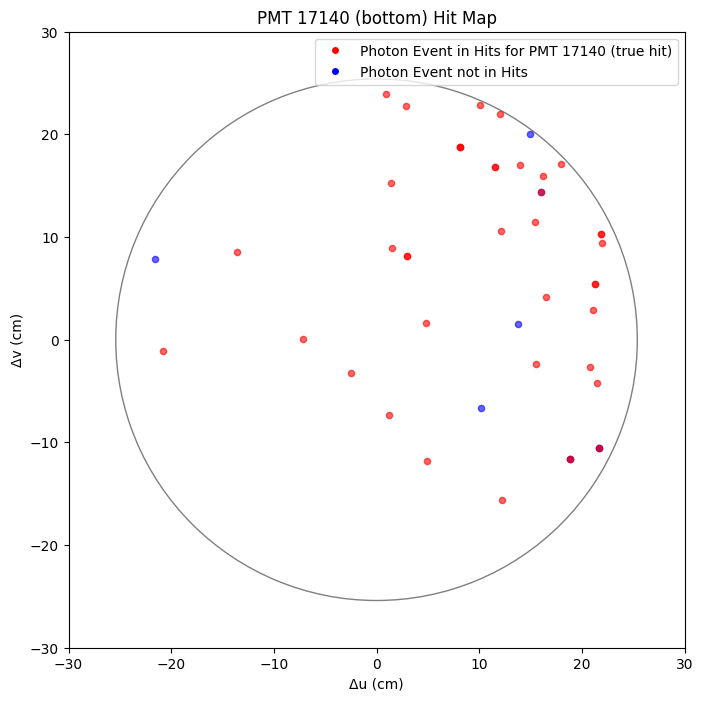

Top 10 PMTs by photon count:
[13007, 19379, 19306, 19308, 19272, 19270, 19343, 19234, 19307, 19342, 19377, 19378, 19344, 19196, 19413, 19412, 19309, 19235, 19198, 19159, 19376, 19160, 19158, 19273, 19341, 19157, 19271, 19195, 19199, 19414, 19237, 19119, 19233, 19197, 19447, 19305, 19446, 19081, 19236, 19411, 19274, 19039, 19345, 19042, 19080, 19304, 19161, 19269, 19445, 19120, 19479, 19118, 19122, 19200, 19380, 19162, 19078, 19310, 19077, 19340, 19079, 19040, 19375, 19238, 19156, 18999, 18958, 18960, 19410, 19232, 19239, 18918, 19041, 19478, 18998, 19002, 19201, 11518, 19082, 19121, 19117, 19448, 19268, 18834, 18959, 19001, 19083, 19194, 18916, 19163, 19415, 19444, 13006, 19038, 18917, 19346, 19231, 18832, 18920, 19043, 19076, 18875, 19381, 19123, 19000, 19155, 19275, 19116, 18915, 18876, 19480, 19339, 19311, 19044, 18919, 18956, 19037, 18873, 18997, 18790, 18749, 18962, 19003, 19124, 18957, 18706, 18750, 18874, 18835, 18877, 19004, 18961, 19303, 18996, 19477, 18872, 19036, 19084, 1870

In [ ]:
# 2D plot of pmt face showing which photons were seen as a hit vs which ones were not registered (estimate)

def pmt_photon_hits(pmt_id, ax=None):
    
    created_fig = False
    
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        created_fig = True
    
    # get all photons associated with this pmt
    pmt_ph_df = ph_df[ph_df["tubeId"] == pmt_id]
    pmt_hit_df = hit_df[hit_df['pmt_id'] == pmt_id]

    # for each item in pmt_ph_df, if there is an entry in pmt_hit_df with the same entry in 'event' column,
    # plot it red. if there is no item in pmt_hit_df with the same event, plot blue
    hit_events = set(pmt_hit_df['event'])
    colors = ['red' if event in hit_events else 'blue' for event in pmt_ph_df['event']]

    # plt.scatter(range(len(pmt_ph_df)), pmt_ph_df['event'], c=colors)
    
    x_ends = pmt_ph_df['endX'].values * 0.1 
    y_ends = pmt_ph_df["endY"].values * 0.1
    z_ends = pmt_ph_df["endZ"].values * 0.1
        
    # PMT position
    pmt_x, pmt_y, pmt_z, type = pmt_dict[pmt_id]
    if type == 'top':
        u = np.array([1,0,0])
        v = np.array([0,-1,0])
    elif type == 'bottom':
        u = np.array([1,0,0])
        v = np.array([0,1,0])
    elif type == 'barrel':
        n = pmt_normals[pmt_ids[0]]
        u = np.cross([0,0,1], n)  # u is perpendicular to both z and n (phi hat)
        u /= np.linalg.norm(u)      # normalize, just in case
        v = np.cross(n, u)          # v is perpendicular to n and u, (should be z hat)

    
    # PMT face
    circle = patches.Circle((0, 0), radius=25.4, color='black', fill=False, alpha=0.5)
    ax.add_patch(circle)

    # loop over hits
    for xe, ye, ze, color in zip(x_ends, y_ends, z_ends, colors):
        pos = np.array([xe, ye, ze]) - np.array([pmt_x, pmt_y, pmt_z])  # relative position to center PMT
        x_proj = np.dot(pos, u)
        y_proj = np.dot(pos, v)
        ax.scatter(x_proj, y_proj, s=20, alpha=0.6, color=color)
        #print(x_proj, y_proj, color)
        
        # there are duplicate photons!! same position, same event
    
    legend_elements = [
        Line2D([0], [0],
            marker='o',
            color='w',
            markerfacecolor='red',
            markersize=6,
            label=f'Photon Event in Hits for PMT {pmt_id} (true hit)'),

        Line2D([0], [0],
            marker='o',
            color='w',
            markerfacecolor='blue',
            markersize=6,
            label='Photon Event not in Hits')
    ]

    ax.legend(handles=legend_elements, loc='upper right')

        # Formatting
    ax.set_aspect('equal')
    ax.set_xlim(-30, 30)
    ax.set_ylim(-30, 30)
    ax.set_xlabel("Δu (cm)")
    ax.set_ylabel("Δv (cm)")
    ax.set_title(f"PMT {pmt_id} ({type}) Hit Map")

    if created_fig:
        plt.show()
    
    return ax

pmt_photon_hits(17140)


# get top 10 pmts by count in ph_df
top_pmts = ph_df["tubeId"].value_counts().head(1000).index.tolist()
print("Top 10 PMTs by photon count:")
print(top_pmts)

136 photons


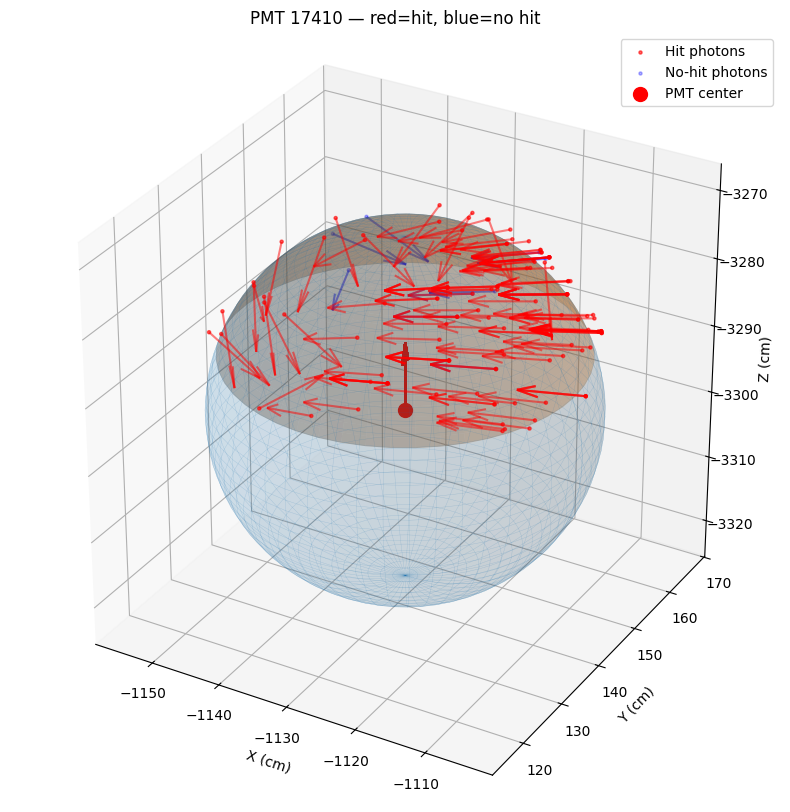

In [ ]:
# 3D version of above

def pmt_photon_hits_3d(pmt_id, max_dist=27, arrow_scale=10):
    # get all photons associated with this pmt
    pmt_ph_df = ph_df[ph_df["tubeId"] == pmt_id]
    pmt_hit_df = hit_df[hit_df['pmt_id'] == pmt_id]
    print(f"{pmt_ph_df.shape[0]} photons")

    # determine hit/no-hit colors
    hit_events = set(pmt_hit_df['event'])
    colors = ['red' if event in hit_events else 'blue' for event in pmt_ph_df['event']]

    nx, ny, nz = pmt_normals[pmt_id]
    # photon end points (convert to cm)
    x = pmt_ph_df["endX"].values * 0.1
    y = pmt_ph_df["endY"].values * 0.1
    z = pmt_ph_df["endZ"].values * 0.1
    # direction vectors
    dx = pmt_ph_df["endDirX"].values
    dy = pmt_ph_df["endDirY"].values
    dz = pmt_ph_df["endDirZ"].values
    norm_xs = pmt_ph_df["normX"].values
    norm_ys = pmt_ph_df["normY"].values
    norm_zs = pmt_ph_df["normZ"].values
    # cent pos
    pmt_x, pmt_y, pmt_z, _ = pmt_dict[pmt_id]

    # plot
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_aspect('equal')

    # pmt sphere
    r = 25.4  # cm
    u = np.linspace(0, 2 * np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    xs = pmt_x + r * np.outer(np.cos(u), np.sin(v))
    ys = pmt_y + r * np.outer(np.sin(u), np.sin(v))
    zs = pmt_z + r * np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(xs, ys, zs, alpha=0.1)
    ax.plot_wireframe(xs, ys, zs, linewidth=0.25, alpha=0.25)

    # cap
    theta = np.deg2rad(70)
    n = np.array([nx, ny, nz])
    n = n / np.linalg.norm(n)
    a = np.array([1, 0, 0])
    if np.allclose(n, a):
        a = np.array([0, 1, 0])
    u_vec = np.cross(n, a)
    u_vec /= np.linalg.norm(u_vec)
    v_vec = np.cross(n, u_vec)

    phi = np.linspace(0, 2 * np.pi, 50)
    theta_vals = np.linspace(0, theta, 25)
    phi, theta_vals = np.meshgrid(phi, theta_vals)
    cap_x, cap_y, cap_z = [], [], []
    for i in range(phi.shape[0]):
        row_x, row_y, row_z = [], [], []
        for j in range(phi.shape[1]):
            dir_vec = (
                np.cos(theta_vals[i, j]) * n +
                np.sin(theta_vals[i, j]) * (
                    np.cos(phi[i, j]) * u_vec + np.sin(phi[i, j]) * v_vec
                )
            )
            pt = np.array([pmt_x, pmt_y, pmt_z]) + r * dir_vec
            row_x.append(pt[0])
            row_y.append(pt[1])
            row_z.append(pt[2])
        cap_x.append(row_x)
        cap_y.append(row_y)
        cap_z.append(row_z)
    ax.plot_surface(np.array(cap_x), np.array(cap_y), np.array(cap_z), alpha=0.3)

    # photon endpoints: red = hit, blue = no hit
    hit_mask = np.array([e in hit_events for e in pmt_ph_df['event']])
    if hit_mask.any():
        ax.scatter(x[hit_mask], y[hit_mask], z[hit_mask],
                   s=5, alpha=0.6, color='red', label="Hit photons")
        ax.quiver(x[hit_mask], y[hit_mask], z[hit_mask], dx[hit_mask], dy[hit_mask], dz[hit_mask],
              length=arrow_scale, normalize=True, alpha=0.5, color='red')
    if (~hit_mask).any():
        ax.scatter(x[~hit_mask], y[~hit_mask], z[~hit_mask],
                   s=5, alpha=0.3, color='blue', label="No-hit photons")
        ax.quiver(x[~hit_mask], y[~hit_mask], z[~hit_mask], dx[~hit_mask], dy[~hit_mask], dz[~hit_mask],
              length=arrow_scale, normalize=True, alpha=0.5, color='blue')

    # direction arrows

    ax.quiver(pmt_x, pmt_y, pmt_z, norm_xs, norm_ys, norm_zs,
              length=arrow_scale, color='red', normalize=True, alpha=0.5)

    # center
    ax.scatter(pmt_x, pmt_y, pmt_z, color='red', s=100, label="PMT center")

    # labels
    ax.set_xlabel("X (cm)")
    ax.set_ylabel("Y (cm)")
    ax.set_zlabel("Z (cm)")
    ax.set_title(f"PMT {pmt_id} — red=hit, blue=no hit")
    ax.legend()
    plt.show()
    
pmt_photon_hits_3d(17410)

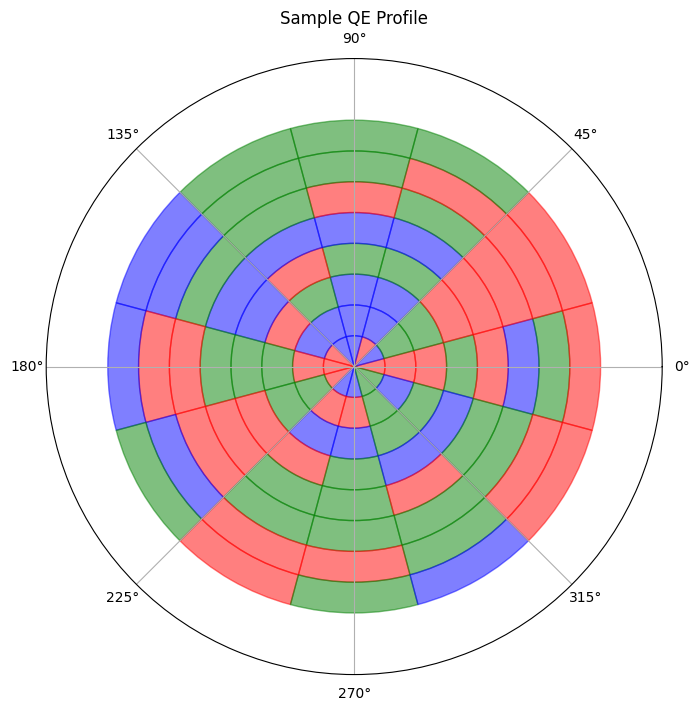

<PolarAxes: title={'center': 'Sample QE Profile'}>

In [ ]:

import random

# placeholder for QE map 

def qe_profile(ax=None):
    created_fig = False

    # Create axis only if none provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
        created_fig = True
    else:
        # Ensure the passed axis is polar
        if ax.name != 'polar':
            raise ValueError("qe_profile requires a polar axis")

    # plot random
    counter = -1
    for i in range(12 * 8):
        color = random.choice(['r', 'g', 'b'])
        if i % 12 == 0:
            counter += 1

        ax.bar(
            i * 2 * np.pi / 12,
            1,
            width=2 * np.pi / 12,
            bottom=counter,
            color=color,
            edgecolor=color,
            alpha=0.5
        )

    # formatting
    ax.set_ylim(0, 10)
    ax.set_title("Sample QE Profile")
    ax.set_yticks([])

    if created_fig:
        plt.show()

    return ax
    
qe_profile()

(141.1999969482422, -2824.0, -3296.47119140625, 'bottom')
33 photons
36 photons
30 photons
26 photons
28 photons
27 photons
33 photons


/var/folders/_s/7j_881g14zd1rn9kv4_hn7nw0000gn/T/ipykernel_89702/2508467033.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


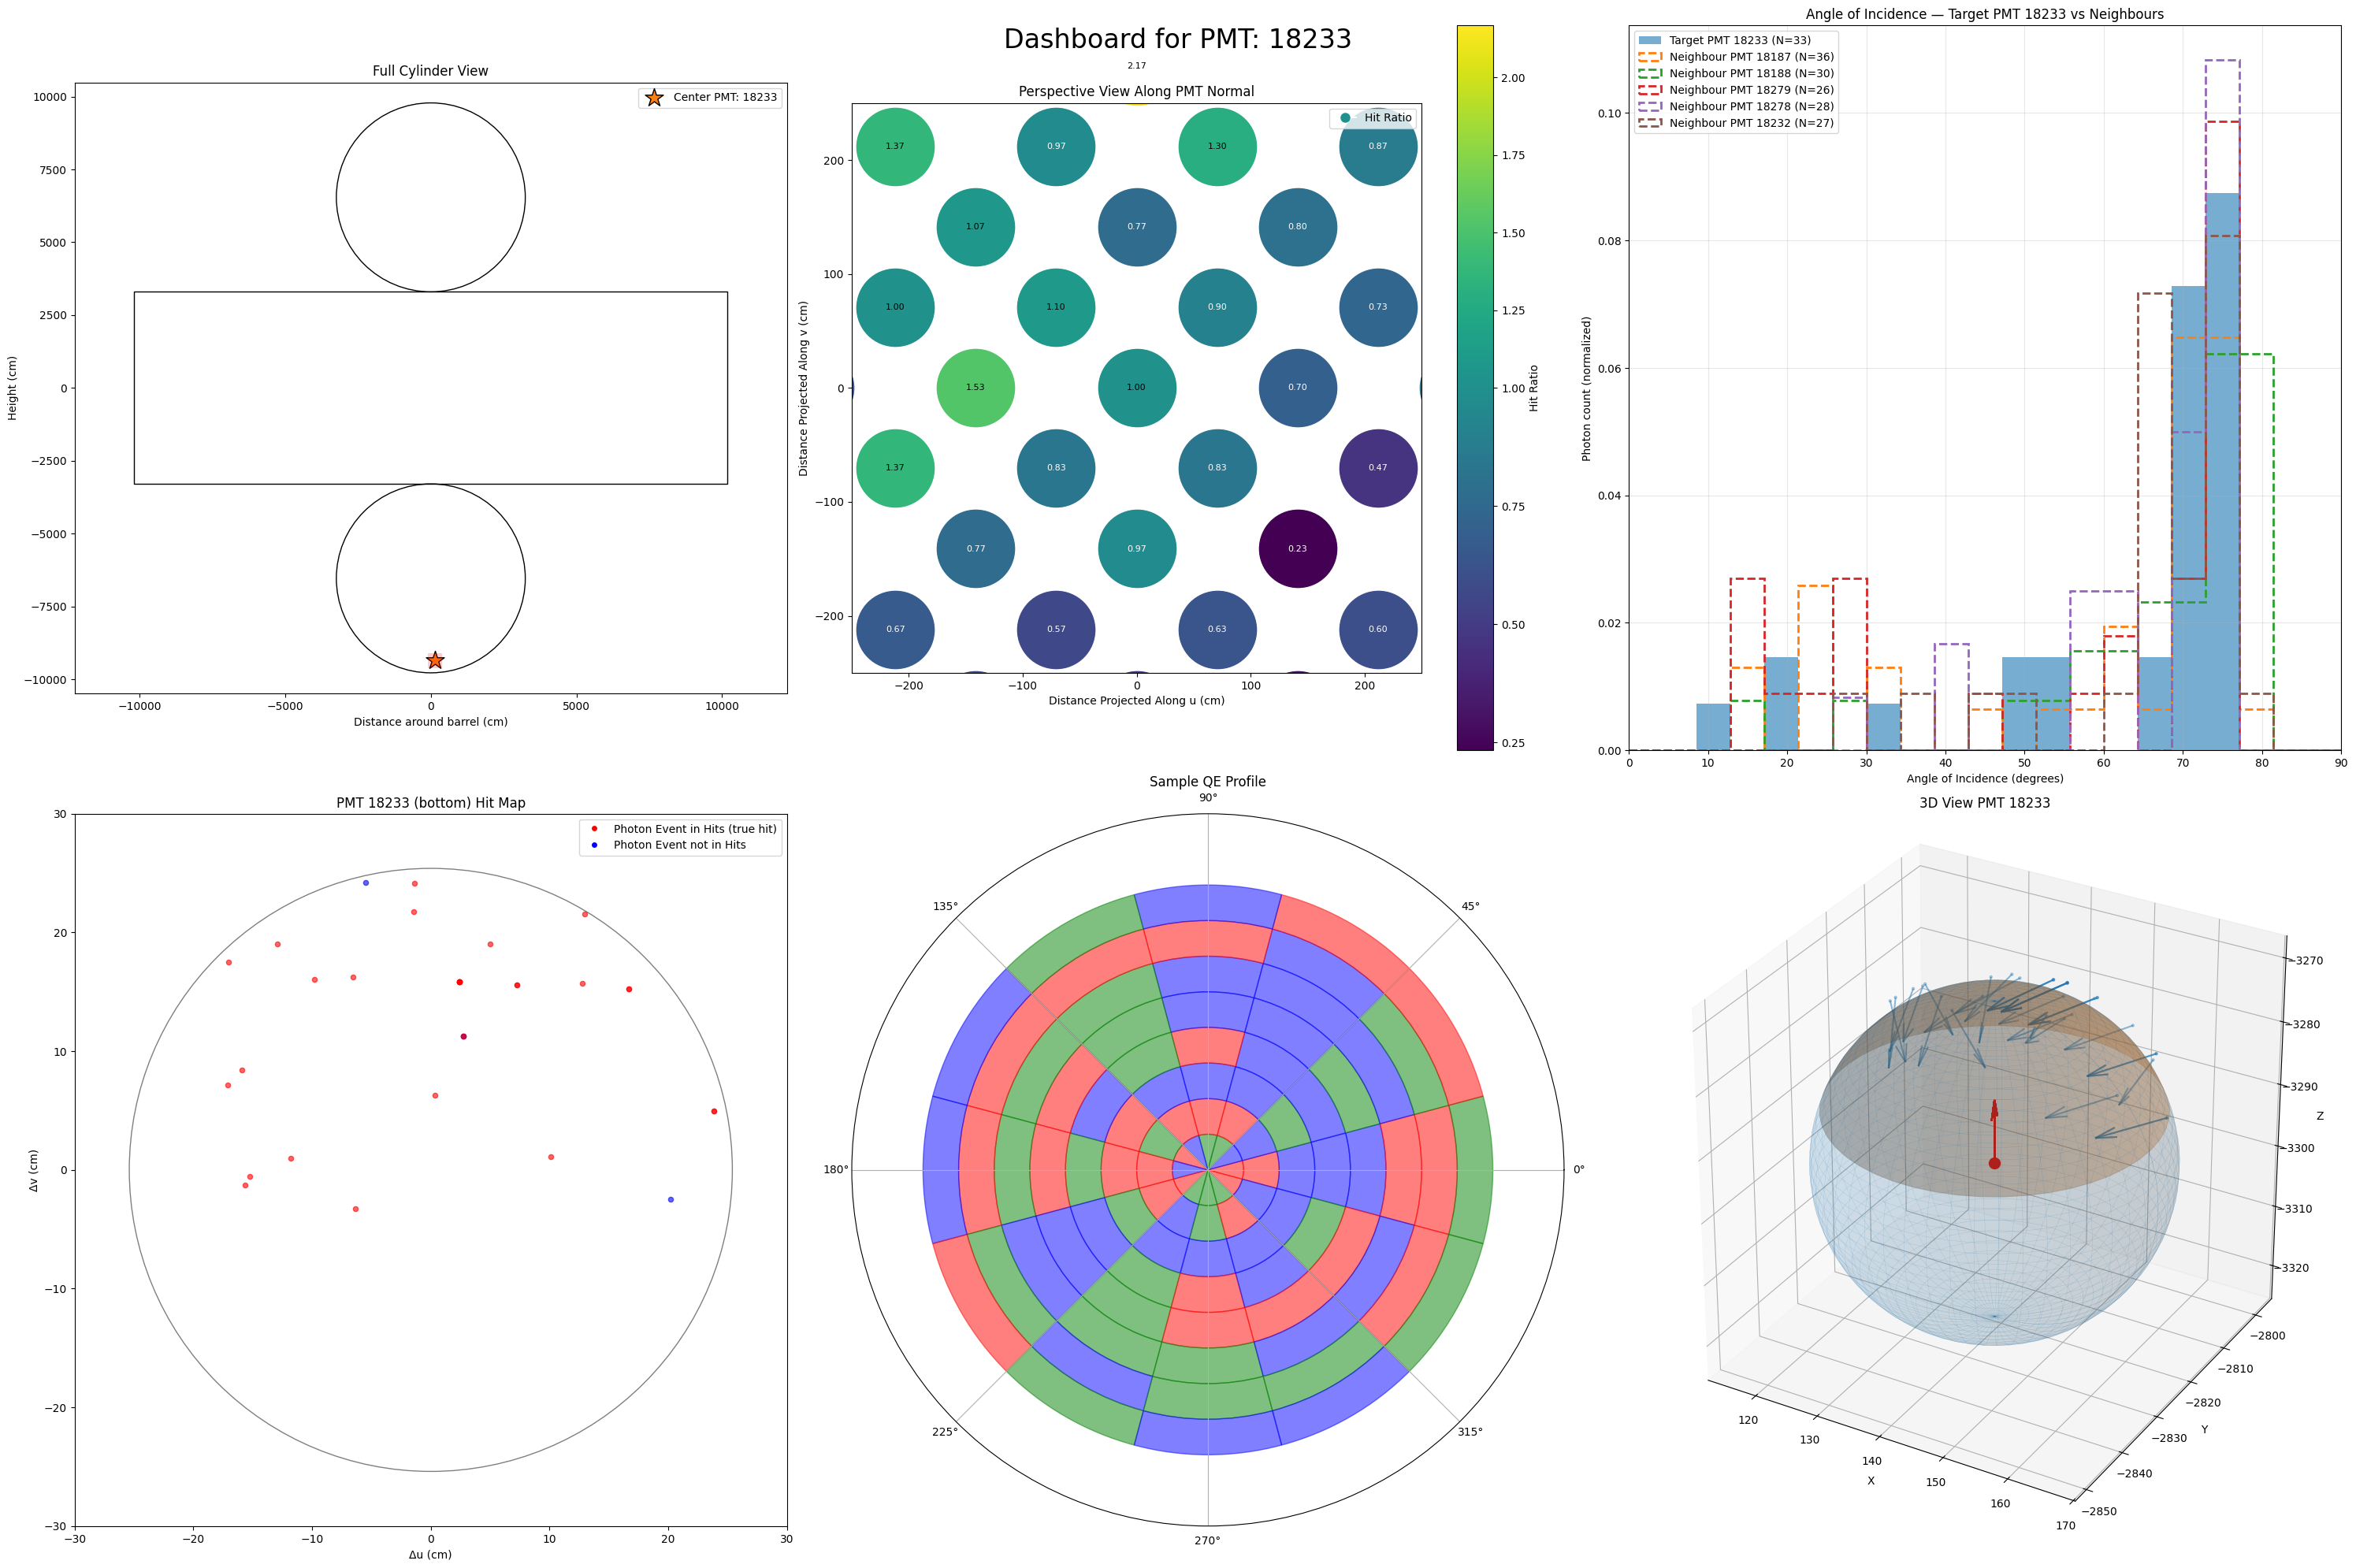

In [230]:
fig = plt.figure(figsize=(30, 20))

axs = [
    fig.add_subplot(2, 3, 1),
    fig.add_subplot(2, 3, 2),
    fig.add_subplot(2, 3, 3),
    fig.add_subplot(2, 3, 4),
    fig.add_subplot(2, 3, 5, projection='polar'),
    fig.add_subplot(2, 3, 6, projection='3d')  # for 3D plot
]

fov_size = 500

info_label = 'Hit Ratio'

dot_size = 5000

num_neighbors = 5

center_pmt = 18233 # some interesting pmts: 18518, 18021, 10676, 18293, 10165, 17770, 13049, 8050, 10113, 17410

neighbors = get_nearest_pmts(center_pmt, 30)
pmt_ids = np.concatenate(([center_pmt], neighbors))
pmt_info = [get_hit_count(pid) for pid in pmt_ids]


pmt_on_cylinder_net(pmt_ids, pmt_info, fov_size, info_label, dot_size, ax_barrel=axs[0])
hit_ratio_of_neighbors(pmt_ids, pmt_info, fov_size, info_label, dot_size, show_vals=True, ax_persp=axs[1])
angle_of_incidence_histogram(center_pmt, num_neighbors, ax=axs[2])
pmt_photon_hits(center_pmt, ax=axs[3])
qe_profile(ax=axs[4])
pmt_view_3d(center_pmt, ax=axs[5])

plt.tight_layout()
fig.suptitle(f"Dashboard for PMT: {center_pmt}", fontsize=24)
plt.show()

